Note: Code snippets and content are on the basis of "Introduction to fastapi" course available on datacamp. Also some contents are AI generated.


# Part 1: Fastapi basics


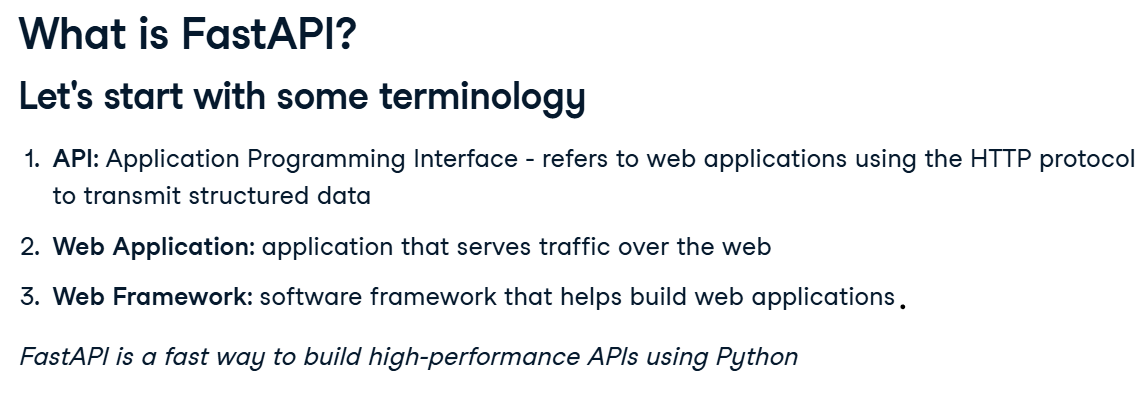

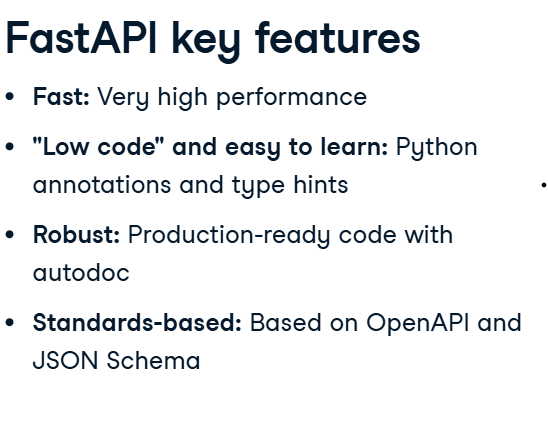

### FastAPI vs. other Python web frameworks
What about other Python web frameworks? Flask and Django are also web frameworks, but both are designed for web-based Graphical User Interface, or GUI, apps instead of APIs.

The big difference between Flask and Django is that Django has a built-in Object-Relational Mapping or ORM for short. An ORM is software that represents database models as Python objects. FastAPI and Flask do not have a built-in ORM. FastAPI's key difference is that it's designed for APIs without database operations, which can hurt API performance. This makes FastAPI a great framework for high-throughput data and machine learning transactions.

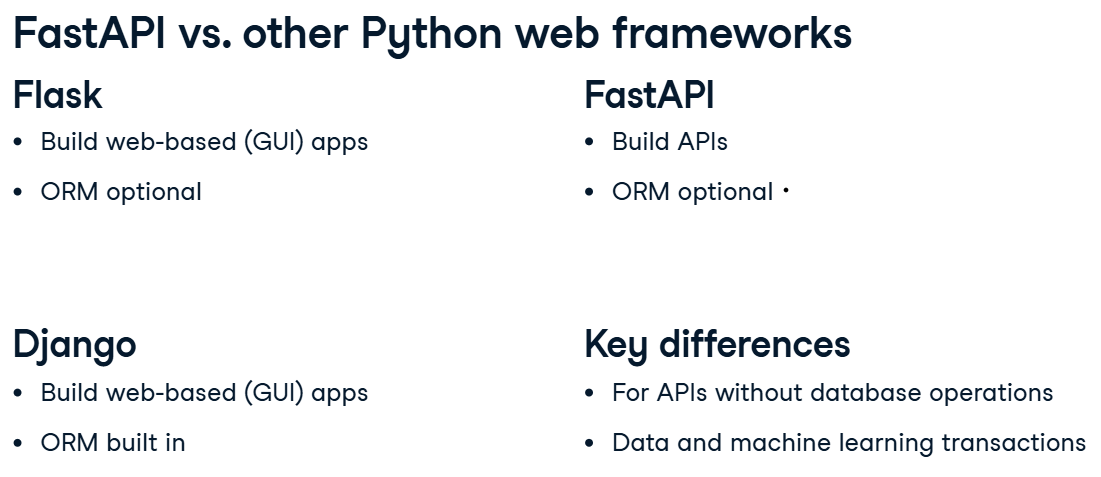

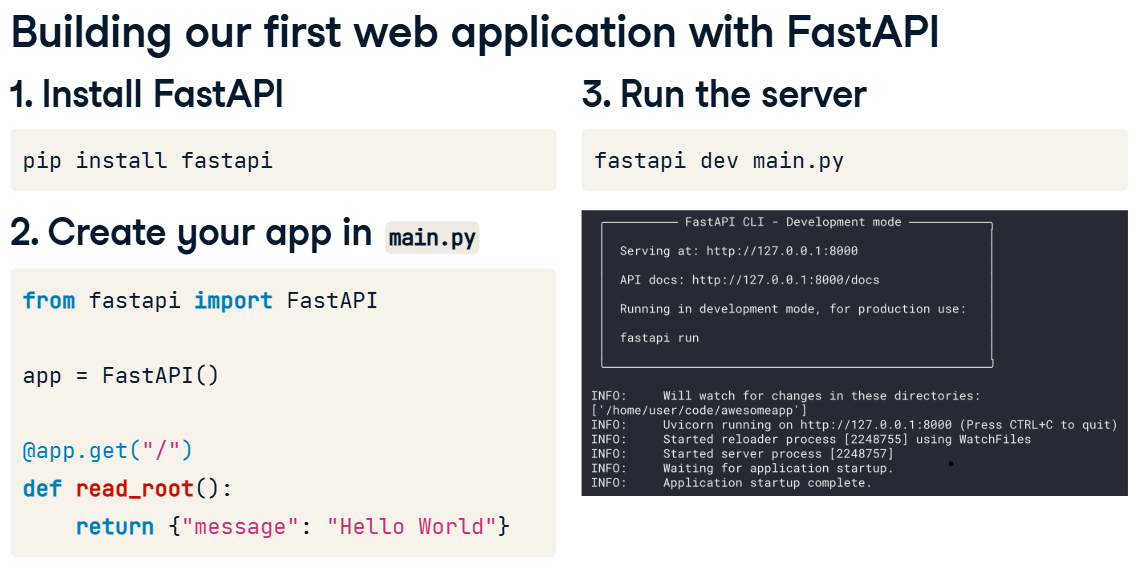

## Get operations
GET is the most common HTTP operation. It is designed to retrieve information rather than send, update, or delete it. When we type a URL into the address bar of our web browser and hit enter, we are sending a GET request.

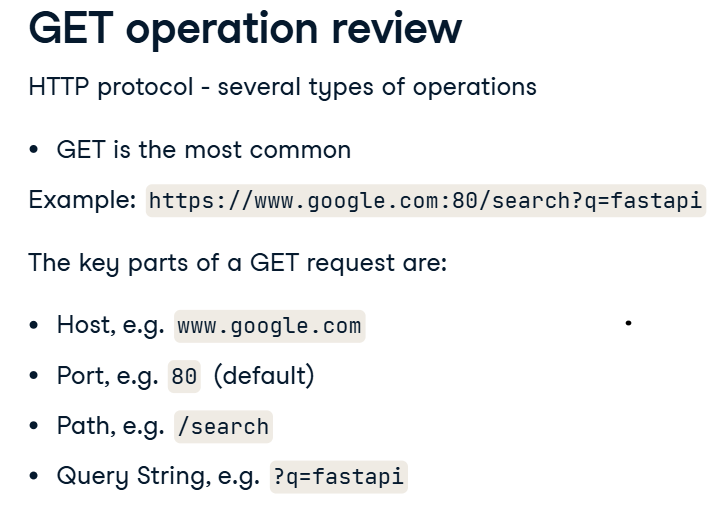

The first key component of the request is the host, in this case, "google.com." This identifies the specific server or load balancer on the Internet where we will send the request. The second key component is the port, in this case 80 which is the default for web serving. The third key component is the path, in this case, "/search." This tells the server what request handler it should use. This is a specific concern of FastAPI, so we will get back to this soon! The fourth key component is the query string. In this case, that is "?q=fastapi." This tells the handler that we are sending a query parameter named "q" with a value of "fastapi." All this put together tells our browser to search Google for the term "fastapi" which will show us the FastAPI project documentation.

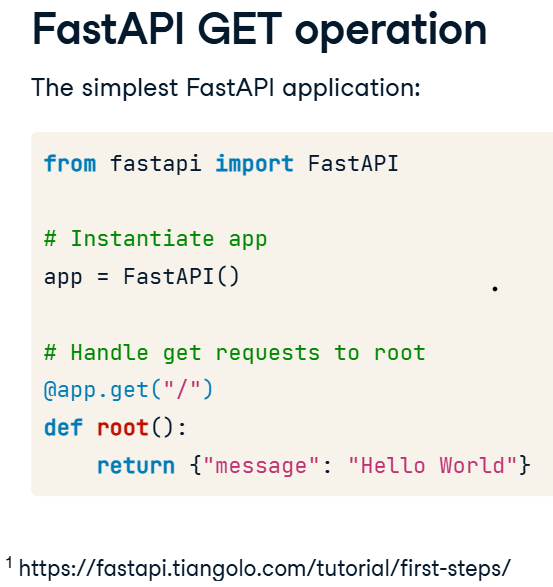

cURL is a convenient script we can use to test our code without a browser. cURL stands for "client URL." The only required argument to cURL is the URL.

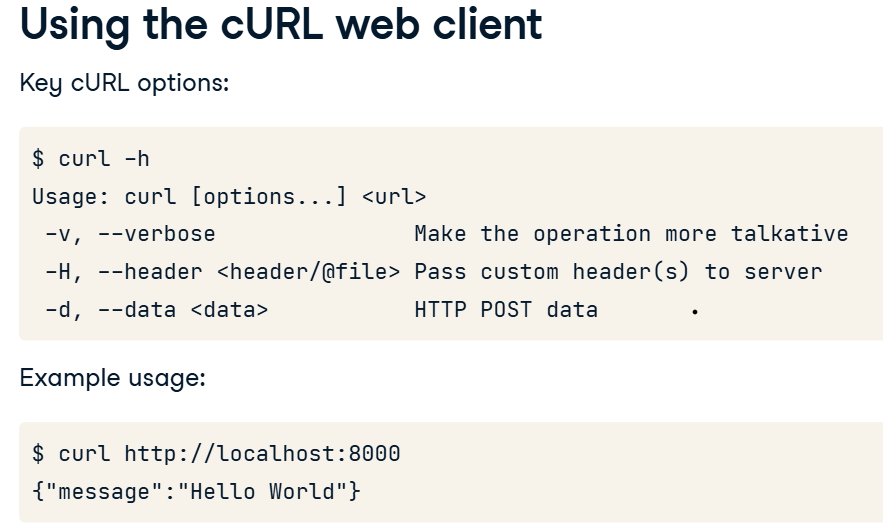

let's make a GET endpoint that supports query parameters. We can add a new path to our application called "hello" that takes an optional parameter called "name" with the default value "Alan."

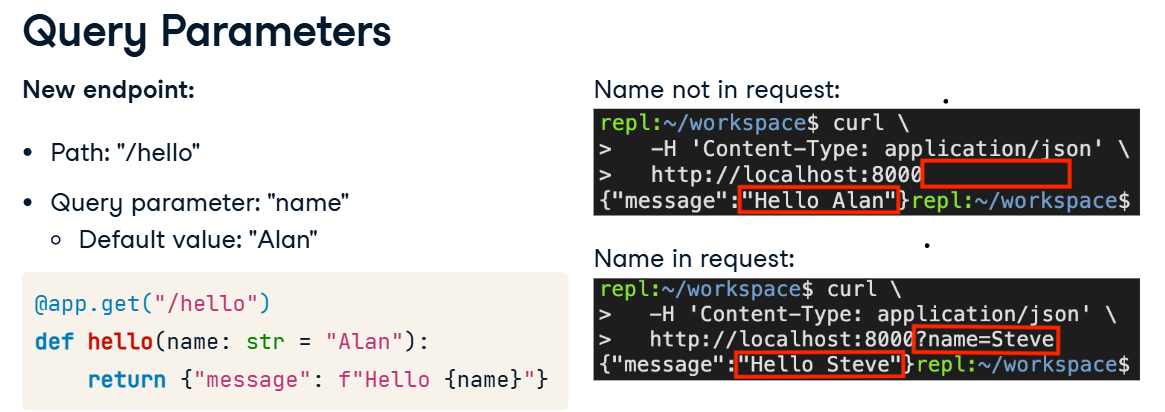

## Post operations

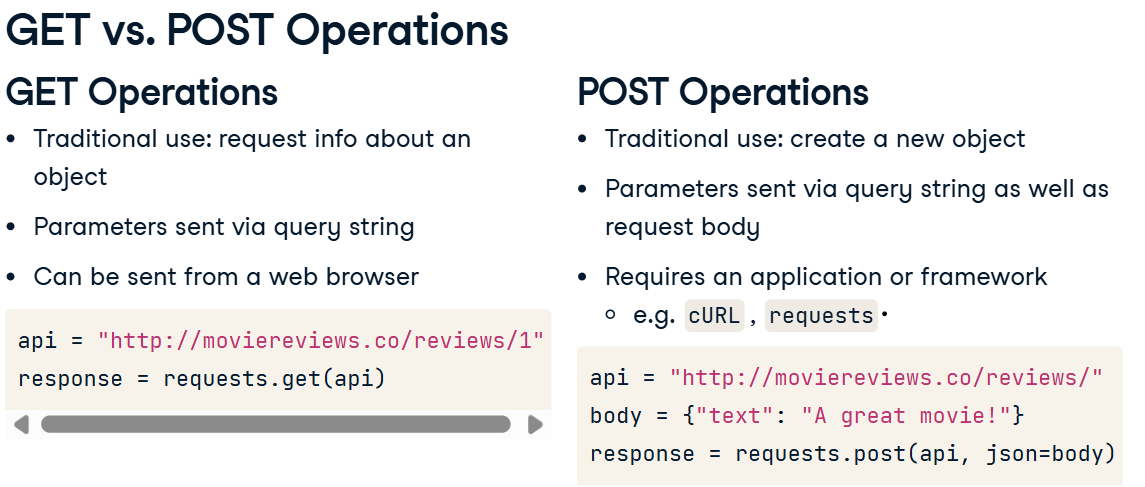

Both HTTP requests and responses can include a message body, which is the data sent after the HTTP header. The header specifies the body encoding, which tells the application how to decode this data correctly, meaning that request bodies support nested data structures. JSON and XML are the most common encodings for APIs.

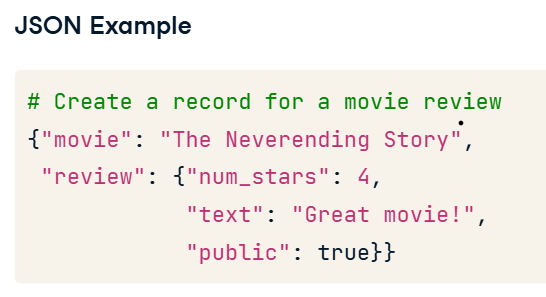

Since HTTP request bodies support nested data structures, we need more than just type hints to define a message body for a POST request. Python's pydantic library is designed to generate and manage nested model schemas. Pydantic model schemas consist of a named model with named and typed attributes, which inherit from the pydantic BaseModel class.

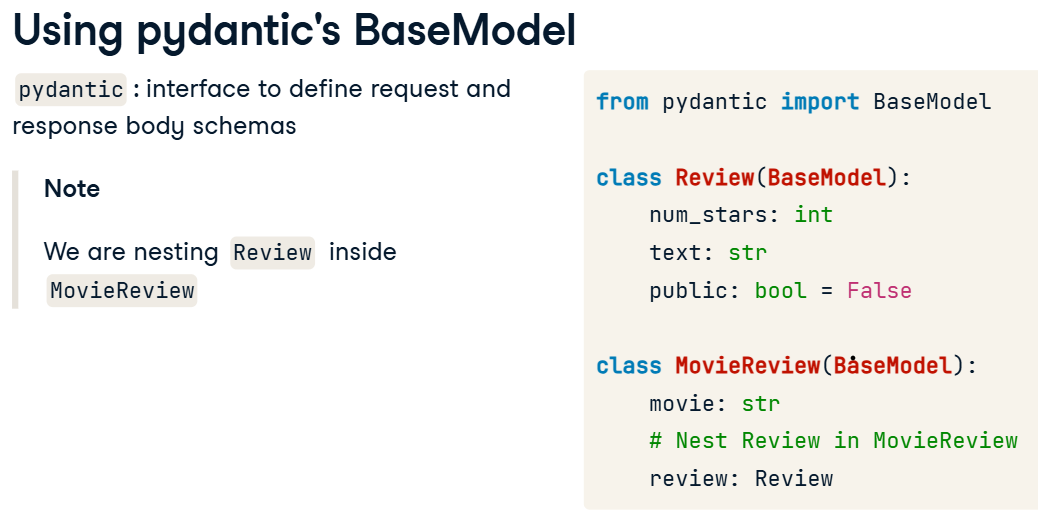

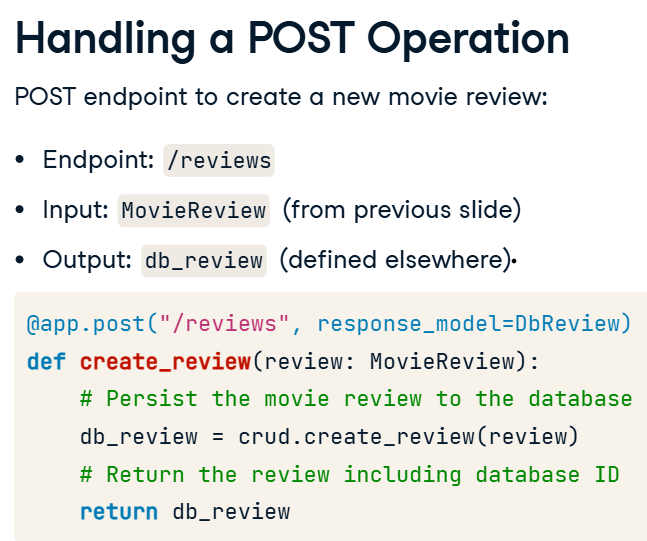



# Part 2: FastAPI advanced topics


## Put and Delete Operations

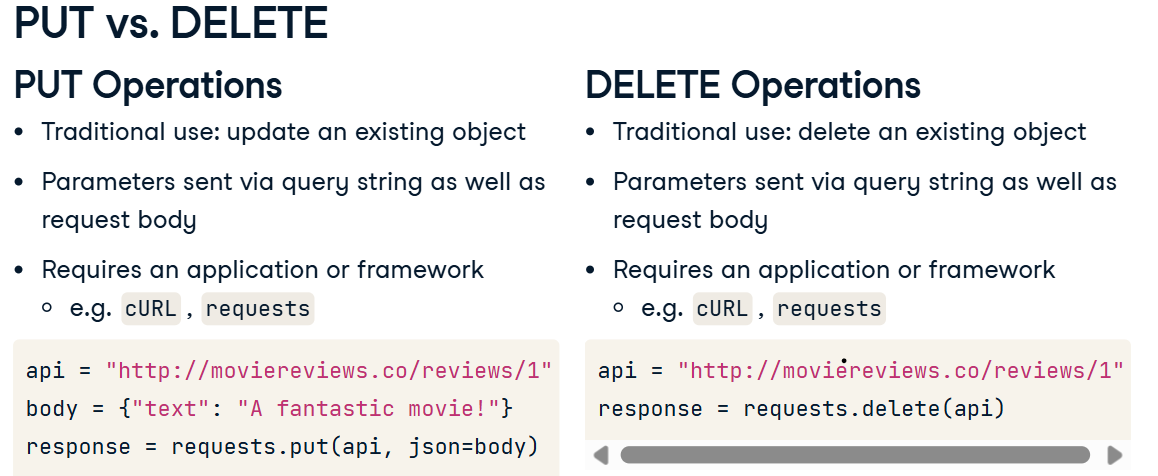

### Referencing existing objects
Referencing existing objects is the most important concept to understand when using PUT and DELETE operations. Frameworks with a built-in ORM handle this mapping for you automatically, but as we have learned, FastAPI does not have a built-in ORM. It is the application's responsibility to map API requests to objects it manages. This typically means mapping a parameter to the ID or other unique column of a database table.

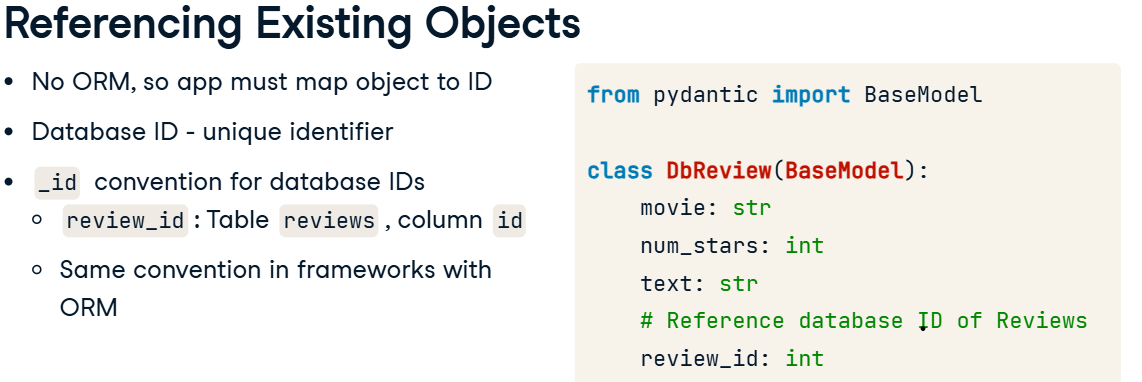

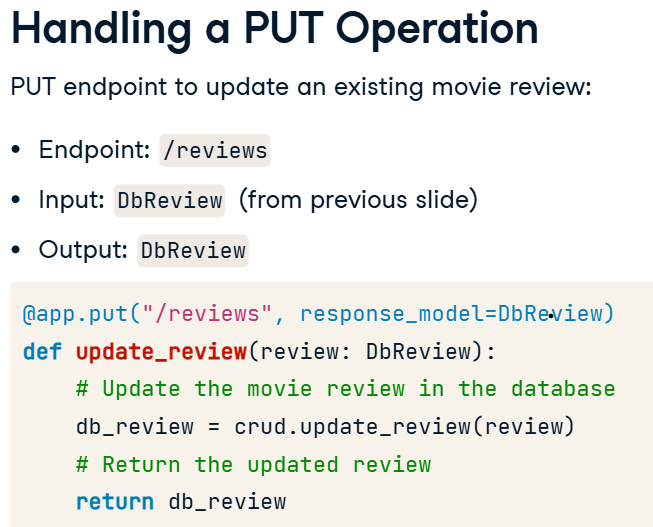

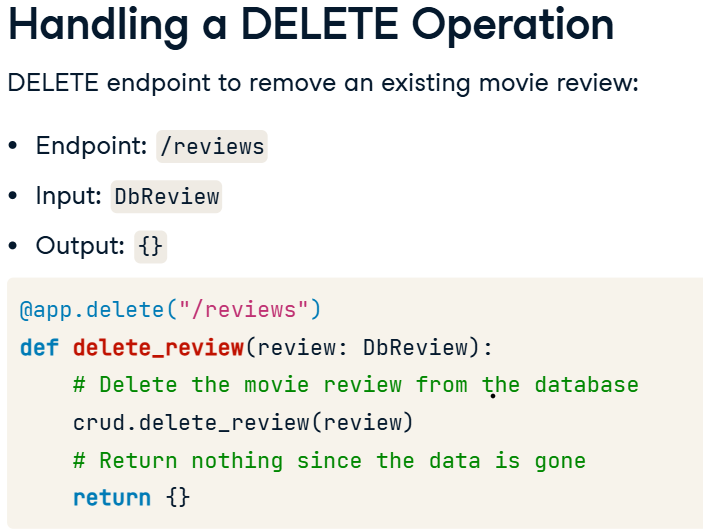

## Handling errors
There are two main reasons for errors. First, errors caused by users of the API. The other main reason for errors is server errors. 

### HTTP status codes
To communicate about the status of requests, APIs use HTTP status codes. Status codes enable APIs to clearly communicate status in every response. Status codes are specifically defined in the HTTP protocol. They range from 100 to 599, and are categorized by their first numbers, 1 through 5. 

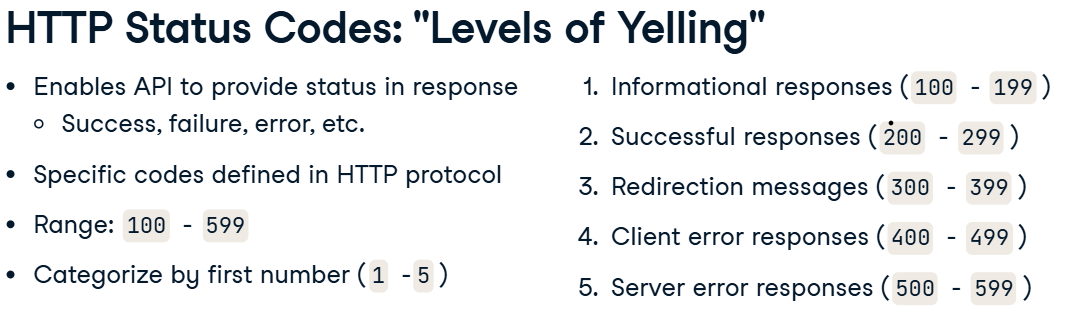

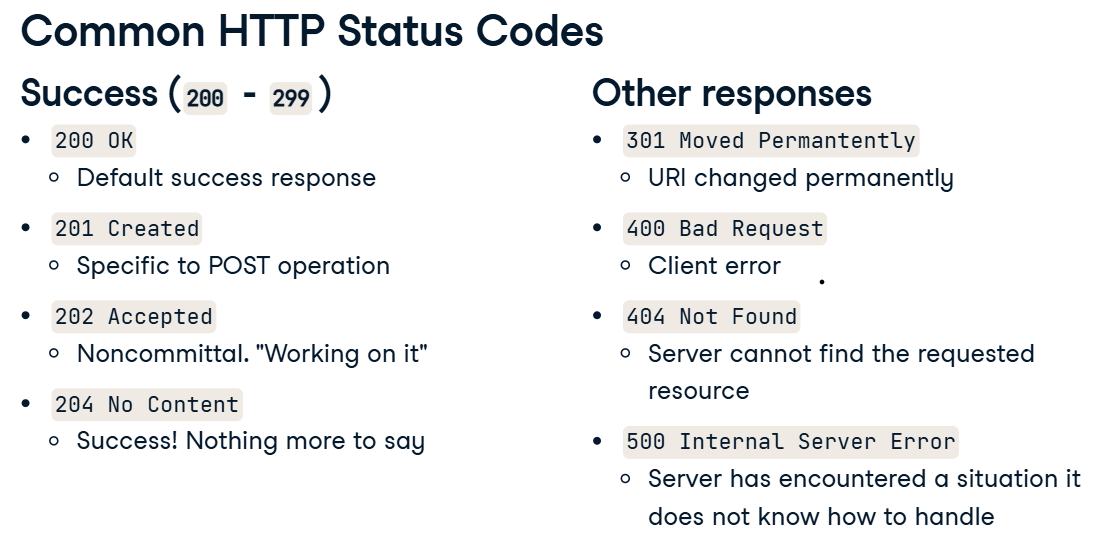

We can't do anything about outside server errors, but we can handle errors within our FastAPI application. We just need to import HTTPException from FastAPI, and raise it with an appropriate status code and detailed message.

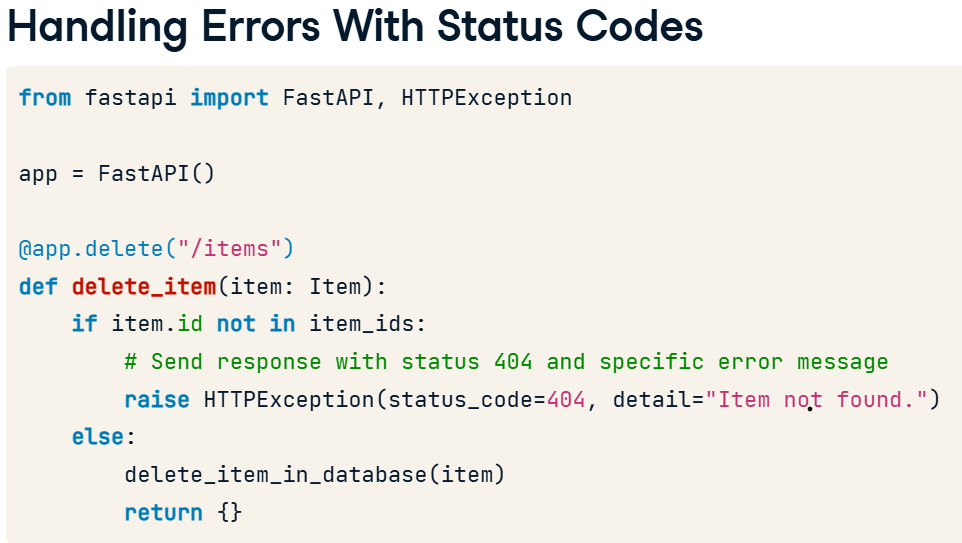

## HTTP status codes
### 🔵 1xx – Informational
These are provisional responses indicating the request was received and understood.

100 Continue – Client should continue with the request.

101 Switching Protocols – Server agrees to switch protocols.

102 Processing – Server has received and is processing the request.

### 🟢 2xx – Success
The request was successfully received, understood, and accepted.

200 OK – Standard response for successful requests.

201 Created – Resource successfully created (POST).

202 Accepted – Request accepted but not yet processed.

204 No Content – Success but no content to return.

### 🟡 3xx – Redirection
Further action needs to be taken to complete the request.

301 Moved Permanently – Resource has permanently moved.

302 Found – Resource temporarily moved.

304 Not Modified – Cached version is still valid.

### 🟠 4xx – Client Errors
The client seems to have made an error.

400 Bad Request – Invalid syntax in the request.

401 Unauthorized – Authentication required or failed.

403 Forbidden – Client is not allowed access.

404 Not Found – Resource not found.

405 Method Not Allowed – Method (e.g., POST, GET) not allowed.

409 Conflict – Request conflicts with server state.

429 Too Many Requests – Rate limit exceeded.

### 🔴 5xx – Server Errors
The server failed to fulfill a valid request.

500 Internal Server Error – Generic server error.

501 Not Implemented – Method not supported.

502 Bad Gateway – Invalid response from upstream server.

503 Service Unavailable – Server is down or overloaded.

504 Gateway Timeout – Upstream server did not respond in time.

## Using Async for concurrent work
async allows non-blocking, concurrent execution — especially useful for I/O-bound tasks (like waiting for APIs, DBs, or files).

### Core Keywords:
async def: Declares an asynchronous function.

await: Pauses execution until the awaited task completes (without blocking other tasks).

-Use async def for endpoints that perform I/O-bound work.

-Avoid async def if you're doing only CPU-bound work — it won’t help (consider concurrent.futures or multiprocessing for that).

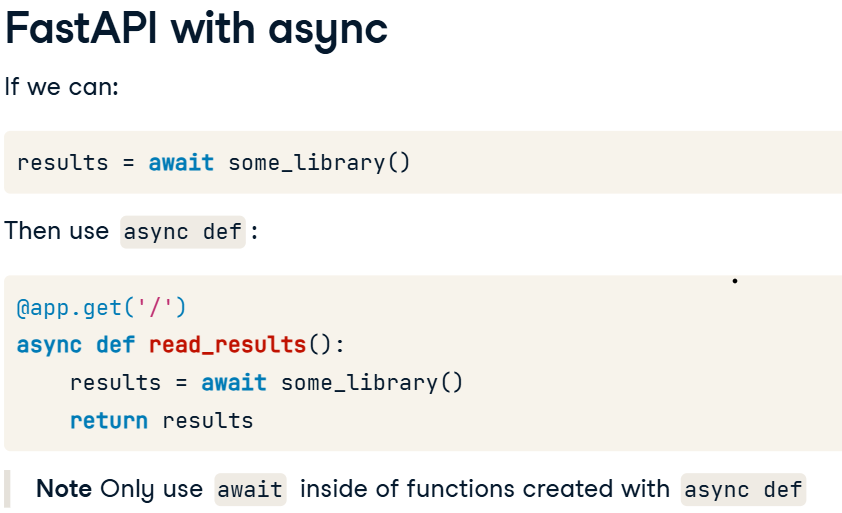

Let's talk about when we should try to use async in FastAPI. The short answer is we should use async if our application doesn't have to communicate with anything else and wait for it to respond. This is true in many instances of data processing, and it is especially helpful when it requires lots of computation that can take a long time to finish. Some examples of this kind of data processing are audio or image processing, computer vision, machine learning, and deep learning. We should not use async when our application must communicate in sync with other systems, for example with a file system, database, or another server. We should also not use async whenever we are not sure that we can.

# Part 3: Building and testing a JSON CRUD API

## FastAPI automated testing

On the left, the unit test can call the function main and validate the dictionary it returns. On the right, the system test can call the actual endpoint, validate the status of the response, and validate that the JSON response parses into the same dictionary.

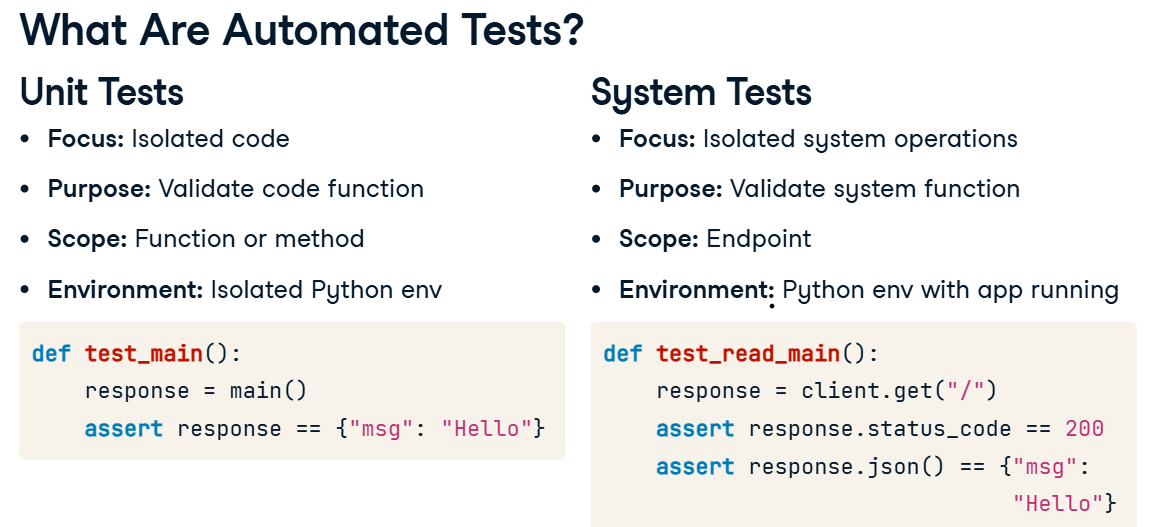

FastAPI lets us write automated system tests just like unit tests. To enable this, the TestClient class lets pytest call the running API and validate its responses. In our system tests, we can import TestClient from fastapi.testclient and import our app from main.py, the local file that defines our FastAPI server. 

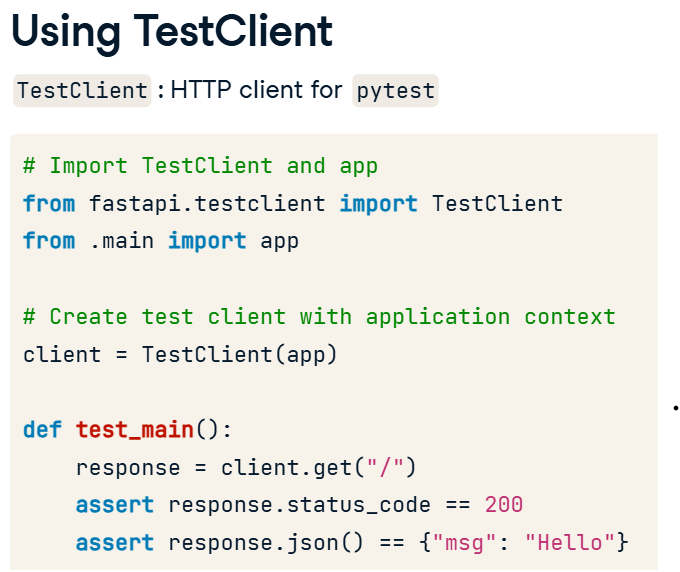

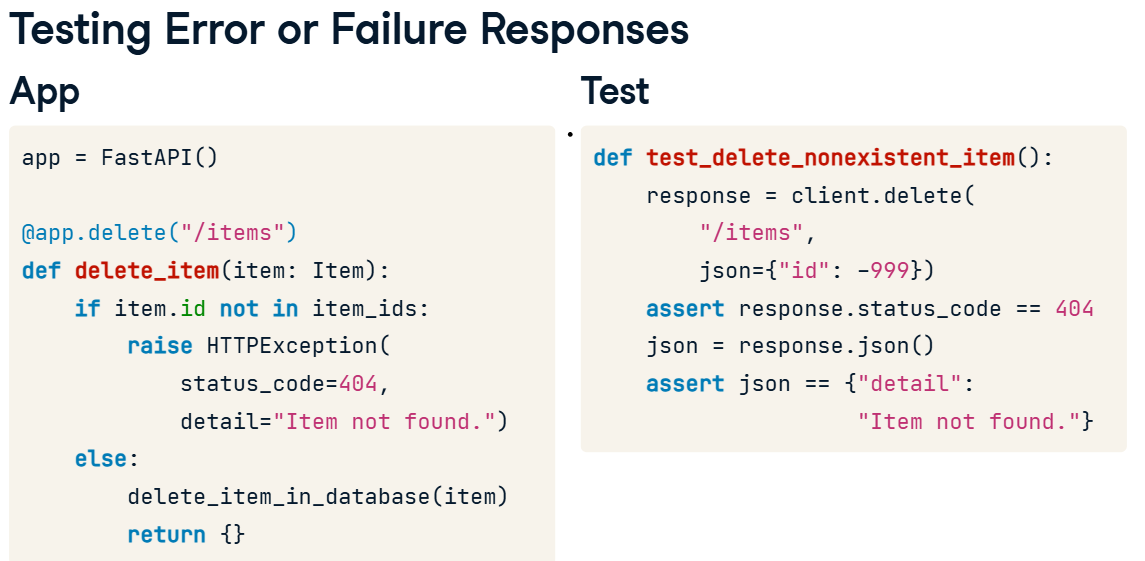

## Building a JSON CRUD API
When we manage objects in a database, there are four steps in the lifecycle.

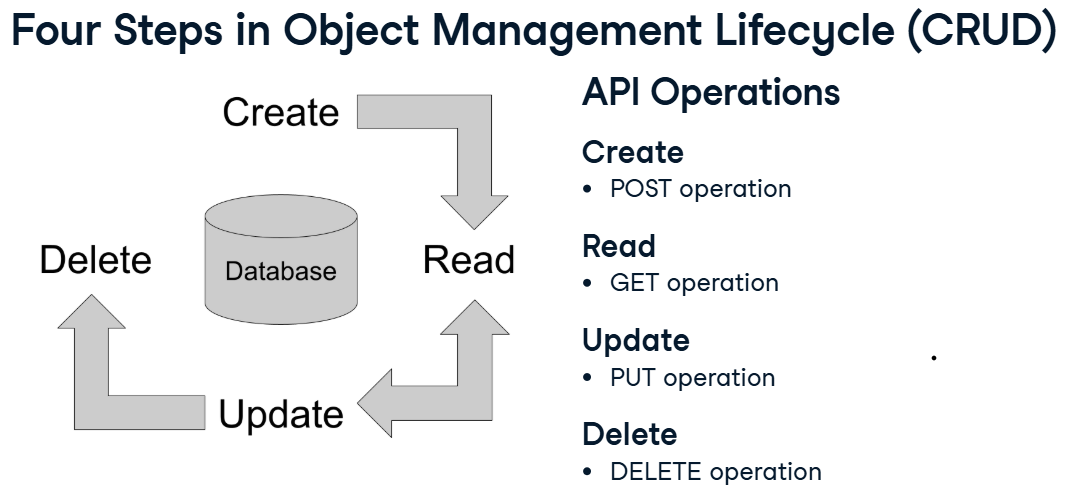

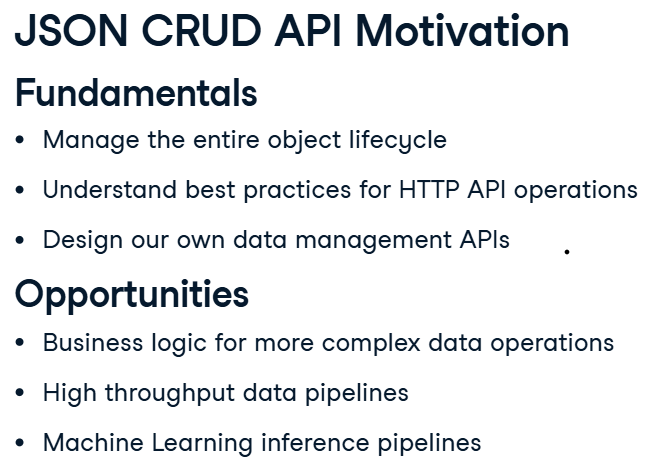

To make it easier to manage database operations from API endpoints, it's common practice to build a CRUD module. 

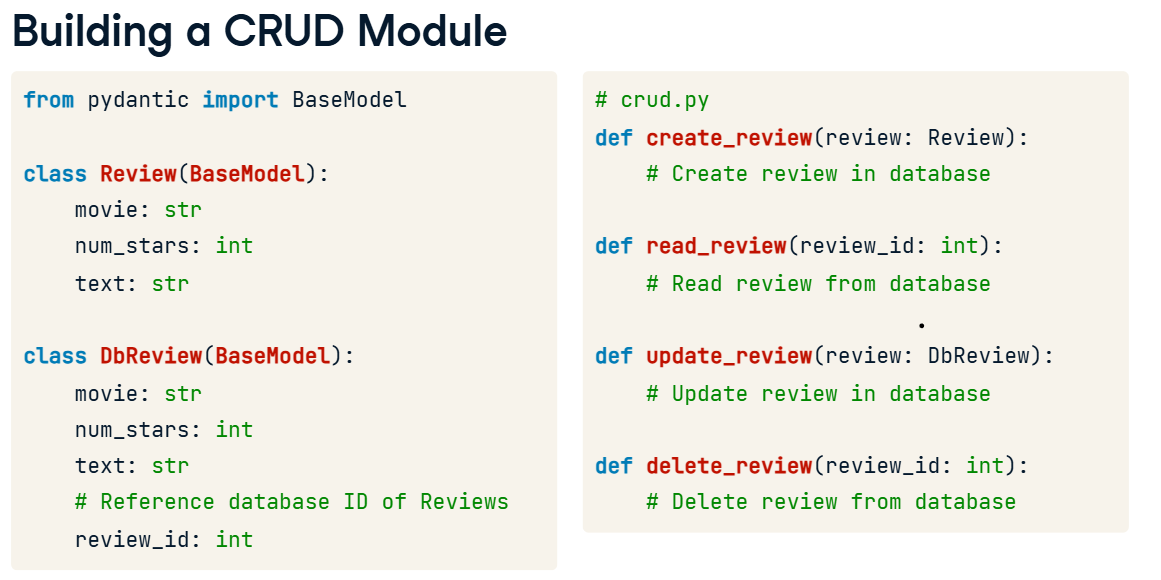

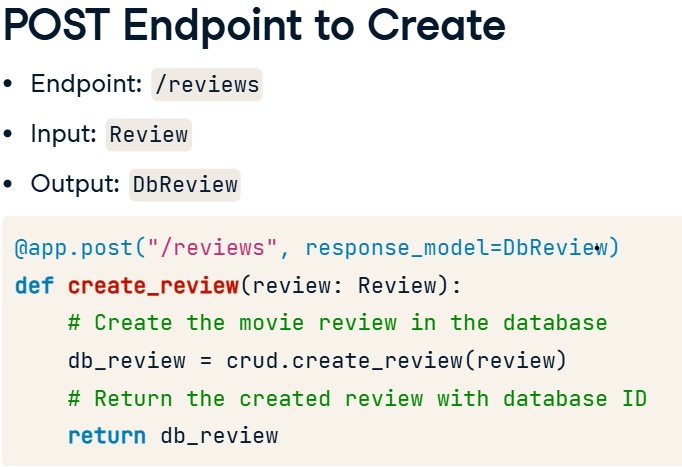

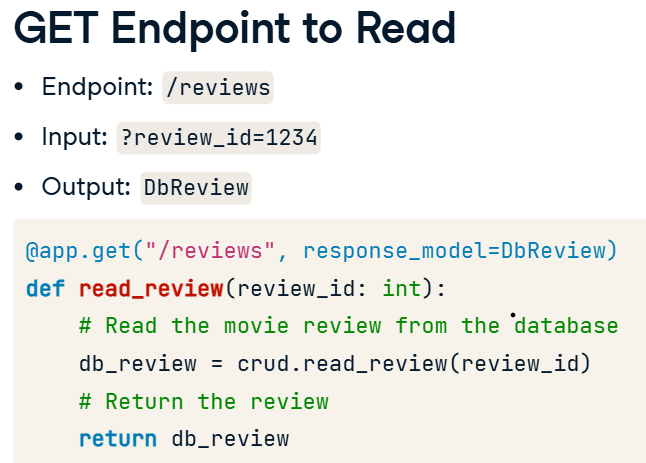

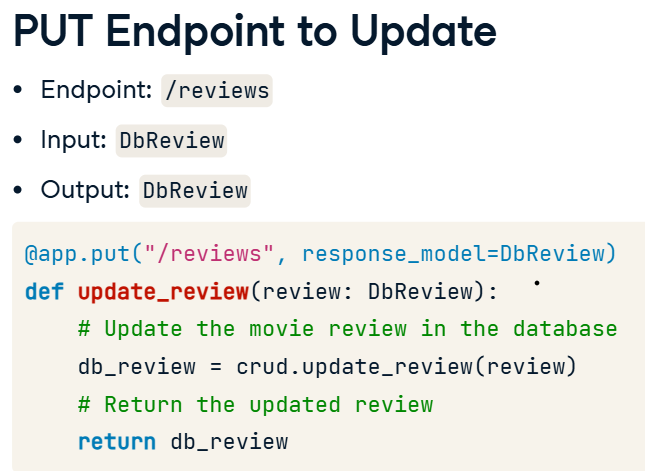

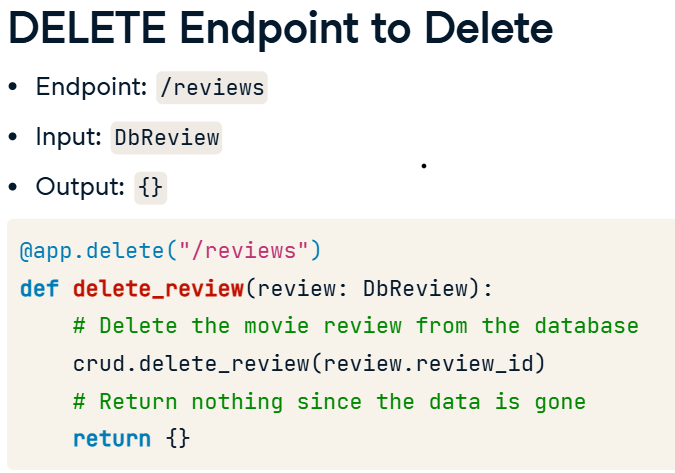

## Writing a manual functional test

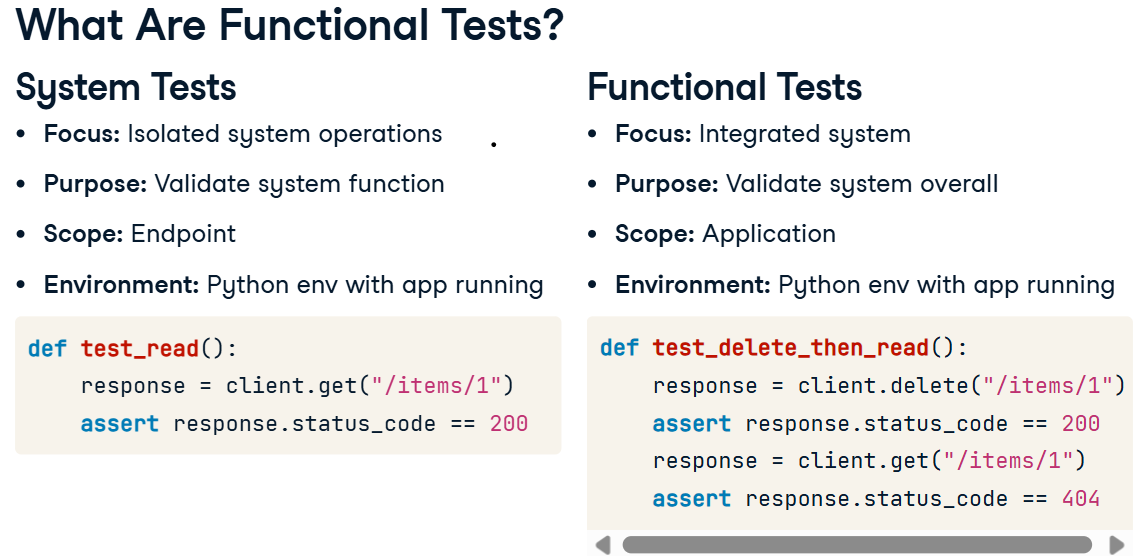

### Test workflows
Test workflows are a critical concept in functional testing. If we just test endpoints randomly, we don't know whether they should succeed in the context of the application or not! Workflows are specific sequences of application actions. Defining workflows forces us to identify endpoint combinations that should succeed or fail. This lets us build functional tests that test the overall application and not just specific endpoints.

### Functional test scripts

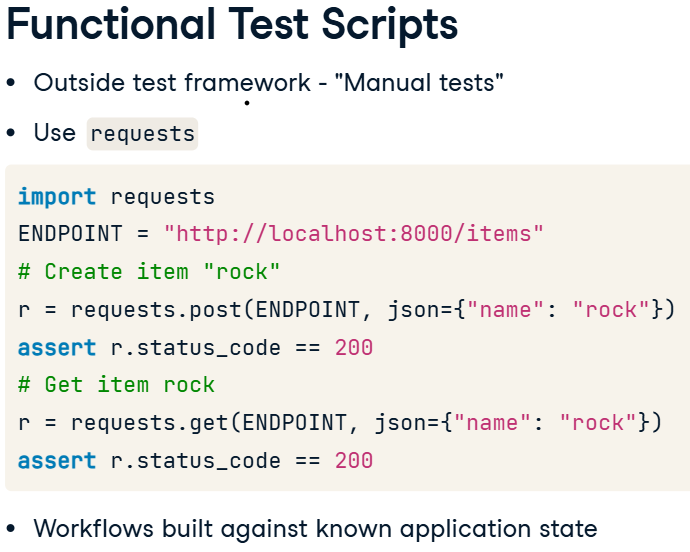

### ✅ 1. Unit Test
Purpose: Test individual components or functions in isolation.

Scope: Smallest testable parts — like classes, methods, or functions.

Who Performs: Typically developers.

Tools: JUnit (Java), pytest (Python), NUnit (.NET), etc.

Example: Testing a function that calculates interest to ensure it returns the correct value for given inputs.

### ✅ 2. Functional Test
Purpose: Verify that the software behaves according to the requirements/specs.

Scope: Tests a specific feature or function from the user’s perspective.

Who Performs: QA engineers or testers.

Tools: Selenium, Postman, Cucumber, etc.

Example: Testing the login feature to confirm users can log in with valid credentials.

Note: Functional testing is often considered a subset of system testing, focused specifically on verifying business logic.

### ✅ 3. System Test
Purpose: Validate the entire system as a whole.

Scope: End-to-end testing of the complete, integrated application.

Who Performs: QA/testing team.

Tools: Selenium, TestComplete, HP ALM, etc.

Example: Simulate a user workflow — log in, search for a product, add to cart, and check out.



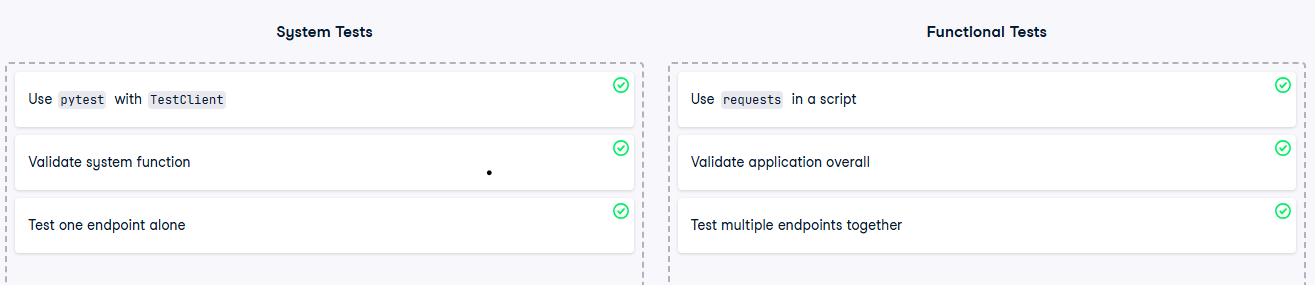